<a href="https://colab.research.google.com/github/MinsooKwak/RAG/blob/main/test/preprocessing/image_embedding_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Arxiv 문서 로더 > 설치  # pymupdf : arxiv.org 사이트에서 다운로드한 PDF 파일을 텍스트 형식)
!pip install -qU langchain-community arxiv pymupdf

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
# PDF 가져올 때
from langchain.document_loaders import PyPDFLoader

"""
# PDF 가져오기
loaders = [
    PyPDFLoader(""),
    PyPDFLoader(""),
]

docs2 = []
for loader in loaders:
  docs2.extend(loader.load())
"""

'\n# PDF 가져오기\nloaders = [\n    PyPDFLoader(""),\n    PyPDFLoader(""),\n]\n\ndocs2 = []\nfor loader in loaders:\n  docs2.extend(loader.load())\n'

In [ ]:
from langchain_community.document_loaders import ArxivLoader

# Query 에 검색하고자 하는 논문의 주제를 입력
loader = ArxivLoader(
    query="Agent",
    load_max_docs= 10,              # 최대 문서 수
    load_all_available_meta=True,   # 메타데이터 전체 로드 여부
)

In [ ]:
# 문서 로드 결과출력
docs = loader.load()
#docs

[Document(metadata={'Published': '2024-07-11', 'Title': 'EvoAgent: Towards Automatic Multi-Agent Generation via Evolutionary Algorithms', 'Authors': 'Siyu Yuan, Kaitao Song, Jiangjie Chen, Xu Tan, Dongsheng Li, Deqing Yang', 'Summary': 'The rise of powerful large language models (LLMs) has spurred a new trend in\nbuilding LLM-based autonomous agents for solving complex tasks, especially\nmulti-agent systems. Despite the remarkable progress, we notice that existing\nworks are heavily dependent on human-designed frameworks, which greatly limits\nthe functional scope and scalability of agent systems. How to automatically\nextend the specialized agent to multi-agent systems to improve task-solving\ncapability still remains a significant challenge. In this paper, we introduce\nEvoAgent, a generic method to automatically extend expert agents to multi-agent\nsystems via the evolutionary algorithm, thereby improving the effectiveness of\nLLM-based agents in solving tasks. Specifically, we cons

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
docs[0].metadata

{'Published': '2024-07-11',
 'Title': 'EvoAgent: Towards Automatic Multi-Agent Generation via Evolutionary Algorithms',
 'Authors': 'Siyu Yuan, Kaitao Song, Jiangjie Chen, Xu Tan, Dongsheng Li, Deqing Yang',
 'Summary': 'The rise of powerful large language models (LLMs) has spurred a new trend in\nbuilding LLM-based autonomous agents for solving complex tasks, especially\nmulti-agent systems. Despite the remarkable progress, we notice that existing\nworks are heavily dependent on human-designed frameworks, which greatly limits\nthe functional scope and scalability of agent systems. How to automatically\nextend the specialized agent to multi-agent systems to improve task-solving\ncapability still remains a significant challenge. In this paper, we introduce\nEvoAgent, a generic method to automatically extend expert agents to multi-agent\nsystems via the evolutionary algorithm, thereby improving the effectiveness of\nLLM-based agents in solving tasks. Specifically, we consider the existin

In [ ]:
docs[0].metadata['links'][-1]

'http://arxiv.org/pdf/2406.14228v2'

In [ ]:
docs[0].page_content

'EVOAGENT: Towards Automatic Multi-Agent\nGeneration via Evolutionary Algorithms\nSiyu Yuan1∗, Kaitao Song2∗†,\nJiangjie Chen1, Xu Tan2, Dongsheng Li2, Deqing Yang1†\nFudan University1, Microsoft Research Asia2\nsyyuan21@m.fudan.edu.cn, {kaitaosong, xuta, dongsli}@microsoft.com\n{jjchen19,yangdeqing}@fudan.edu.cn\nhttps://evo-agent.github.io\nAbstract\nThe rise of powerful large language models (LLMs) has spurred a new trend in\nbuilding LLM-based autonomous agents for solving complex tasks, especially\nmulti-agent systems. Despite the remarkable progress, we notice that existing\nworks are heavily dependent on human-designed frameworks, which greatly limits\nthe functional scope and scalability of agent systems. How to automatically extend\nthe specialized agent to multi-agent systems to improve task-solving capability\nstill remains a significant challenge. In this paper, we introduce EVOAGENT, a\ngeneric method to automatically extend expert agents to multi-agent systems via\nthe ev

In [ ]:
pd.DataFrame(docs[0])

,0,1
0,id,None
1,metadata,"{'Published': '2024-07-11', 'Title': 'EvoAgent..."
2,page_content,EVOAGENT: Towards Automatic Multi-Agent\nGener...
3,type,Document


In [ ]:
docs_df = pd.DataFrame(docs)
docs_df

,0,1,2,3
0,"(id, None)","(metadata, {'Published': '2024-07-11', 'Title'...","(page_content, EVOAGENT: Towards Automatic Mul...","(type, Document)"
1,"(id, None)","(metadata, {'Published': '2020-11-02', 'Title'...","(page_content, Cooperative Heterogeneous Deep ...","(type, Document)"
2,"(id, None)","(metadata, {'Published': '2023-08-21', 'Title'...","(page_content, Improving of Robotic Virtual Ag...","(type, Document)"


In [ ]:
import pandas as pd
from langchain.document_loaders import ArxivLoader

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query="Agent",
    load_max_docs=20,              # 최대 문서 수
    load_all_available_meta=True   # 메타데이터 전체 로드 여부
)
docs = loader.load()

# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

In [ ]:
dataframe

,Title,Summary,PDF Link
0,EvoAgent: Towards Automatic Multi-Agent Genera...,The rise of powerful large language models (LL...,http://arxiv.org/pdf/2406.14228v2
1,Cooperative Heterogeneous Deep Reinforcement L...,Numerous deep reinforcement learning agents ha...,http://arxiv.org/pdf/2011.00791v1
2,Improving of Robotic Virtual Agent's errors th...,One way to improve the relationship between hu...,http://arxiv.org/pdf/2304.00247v2


In [ ]:
!pip install doclayout-yolo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.2/708.2 kB 21.6 MB/s eta 0:00:00


In [ ]:
# DocLayout-YOLO 설치
import os
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image")
os.system("sudo apt-get install poppler-utils")

0

In [ ]:
import cv2
from doclayout_yolo import YOLOv10
from pdf2image import convert_from_path

In [ ]:
"""
# PDF 다운로드 함수
def download_pdf(pdf_url, filename):
    import requests
    response = requests.get(pdf_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded: {filename}")

# PDF를 이미지로 변환
def convert_pdf_to_images(pdf_path, output_dir):
    try:
        os.makedirs(output_dir, exist_ok=True)
        images = convert_from_path(pdf_path)
        image_paths = []
        for i, image in enumerate(images):
            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")
            image.save(image_path, "JPEG")
            image_paths.append(image_path)
        print(f"Converted {pdf_path} to images in {output_dir}")
        return image_paths
    except Exception as e:
        print(f"Error converting {pdf_path} to images: {e}")
        return []

# DocLayout-YOLO를 활용한 이미지, 표, 그래프 추출 함수 (demo.py 실행 방식 사용)
def extract_content_with_doclayout_yolo(image_paths, output_dir):
    model_path = "path/to/model"  # DocLayout-YOLO 모델 경로
    os.makedirs(output_dir, exist_ok=True)
    for image_path in image_paths:
        output_image_dir = os.path.join(output_dir, "images")
        output_table_dir = os.path.join(output_dir, "tables")
        output_graph_dir = os.path.join(output_dir, "graphs")

        os.makedirs(output_image_dir, exist_ok=True)
        os.makedirs(output_table_dir, exist_ok=True)
        os.makedirs(output_graph_dir, exist_ok=True)

        command = (
            f"python demo.py --model {model_path} --image-path {image_path} "
            f"--output {output_dir} --output-images {output_image_dir} "
            f"--output-tables {output_table_dir} --output-graphs {output_graph_dir}"
        )
        os.system(command)
    print(f"Content extracted and saved to {output_dir}")

# PDF 다운로드 및 콘텐츠 추출 함수
def save_pdfs_and_extract_content(dataframe):
    extracted_data_dir = "extracted_data"
    os.makedirs(extracted_data_dir, exist_ok=True)

    for index, row in dataframe.iterrows():
        pdf_link = row['PDF Link']
        title = row['Title']
        if pdf_link:
            pdf_filename = os.path.join(extracted_data_dir, f"paper_{index+1}.pdf")
            download_pdf(pdf_link, pdf_filename)

            # PDF를 이미지로 변환
            image_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_images")
            image_paths = convert_pdf_to_images(pdf_filename, image_output_dir)

            if image_paths:
                # 이미지, 표, 그래프 추출
                content_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_content")
                extract_content_with_doclayout_yolo(image_paths, content_output_dir)
                print(f"Extracted content from {pdf_filename} saved to {content_output_dir}")

# 함수 실행
save_pdfs_and_extract_content(dataframe)
"""

'\n# PDF 다운로드 함수\ndef download_pdf(pdf_url, filename):\n    import requests\n    response = requests.get(pdf_url)\n    with open(filename, \'wb\') as f:\n        f.write(response.content)\n    print(f"Downloaded: {filename}")\n\n# PDF를 이미지로 변환\ndef convert_pdf_to_images(pdf_path, output_dir):\n    try:\n        os.makedirs(output_dir, exist_ok=True)\n        images = convert_from_path(pdf_path)\n        image_paths = []\n        for i, image in enumerate(images):\n            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")\n            image.save(image_path, "JPEG")\n            image_paths.append(image_path)\n        print(f"Converted {pdf_path} to images in {output_dir}")\n        return image_paths\n    except Exception as e:\n        print(f"Error converting {pdf_path} to images: {e}")\n        return []\n\n# DocLayout-YOLO를 활용한 이미지, 표, 그래프 추출 함수 (demo.py 실행 방식 사용)\ndef extract_content_with_doclayout_yolo(image_paths, output_dir):\n    model_path = "path/to/model"  # DocLa

In [ ]:
"""
import cv2
from doclayout_yolo import YOLOv10
from huggingface_hub import hf_hub_download

# Load the pre-trained model
#model = YOLOv10()
filepath = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
model = YOLOv10(filepath)

# Perform prediction
det_res = model.predict(
    "path/to/image",   # Image to predict
    imgsz=1024,        # Prediction image size
    conf=0.2,          # Confidence threshold
    device="cuda:0"    # Device to use (e.g., 'cuda:0' or 'cpu')
)

# Annotate and save the result
annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)
cv2.imwrite("result.jpg", annotated_frame)
"""

'\nimport cv2\nfrom doclayout_yolo import YOLOv10\nfrom huggingface_hub import hf_hub_download\n\n# Load the pre-trained model\n#model = YOLOv10()\nfilepath = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")\nmodel = YOLOv10(filepath)\n\n# Perform prediction\ndet_res = model.predict(\n    "path/to/image",   # Image to predict\n    imgsz=1024,        # Prediction image size\n    conf=0.2,          # Confidence threshold\n    device="cuda:0"    # Device to use (e.g., \'cuda:0\' or \'cpu\')\n)\n\n# Annotate and save the result\nannotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)\ncv2.imwrite("result.jpg", annotated_frame)\n'

### 원본으로 저장

In [ ]:
# Total Image 예측
"""
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
import cv2
from doclayout_yolo import YOLOv10
from PIL import Image

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query="Agent",
    load_max_docs=20,              # 최대 문서 수
    load_all_available_meta=True   # 메타데이터 전체 로드 여부
)
docs = loader.load()

# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

# DocLayout-YOLO 및 필수 패키지 설치
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image huggingface_hub")
os.system("sudo apt-get install poppler-utils")

# PDF 다운로드 함수
def download_pdf(pdf_url, filename):
    import requests
    response = requests.get(pdf_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded: {filename}")

# PDF를 이미지로 변환
def convert_pdf_to_images(pdf_path, output_dir):
    try:
        os.makedirs(output_dir, exist_ok=True)
        images = convert_from_path(pdf_path)
        image_paths = []
        for i, image in enumerate(images):
            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")
            image.save(image_path, "JPEG")
            image_paths.append(image_path)
        print(f"Converted {pdf_path} to images in {output_dir}")
        return image_paths
    except Exception as e:
        print(f"Error converting {pdf_path} to images: {e}")
        return []

# DocLayout-YOLO를 활용한 디텍션 및 저장
def extract_content_with_doclayout_yolo(image_paths, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    # Pre-trained 모델 다운로드 및 로드
    model_path = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
    model = YOLOv10(model_path)

    for image_path in image_paths:
        # 모델 예측
        det_res = model.predict(
            image_path,   # 이미지 경로
            imgsz=1024,   # 예측 이미지 크기
            conf=0.2,     # 신뢰도 임계값
            device="cpu"  # CPU에서 실행
        )

        # 결과 주석 및 저장
        annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)
        output_image_path = os.path.join(output_dir, os.path.basename(image_path))
        annotated_frame = Image.fromarray(annotated_frame)
        annotated_frame.save(output_image_path)
        print(f"Annotated result saved to {output_image_path}")

# PDF 다운로드 및 콘텐츠 추출 함수
def save_pdfs_and_extract_content(dataframe):
    extracted_data_dir = "extracted_data"
    os.makedirs(extracted_data_dir, exist_ok=True)

    for index, row in dataframe.iterrows():
        pdf_link = row['PDF Link']
        title = row['Title']
        if pdf_link:
            pdf_filename = os.path.join(extracted_data_dir, f"paper_{index+1}.pdf")
            download_pdf(pdf_link, pdf_filename)

            # PDF를 이미지로 변환
            image_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_images")
            image_paths = convert_pdf_to_images(pdf_filename, image_output_dir)

            if image_paths:
                # DocLayout-YOLO 디텍션 및 결과 저장
                content_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_content")
                extract_content_with_doclayout_yolo(image_paths, content_output_dir)
                print(f"Extracted content from {pdf_filename} saved to {content_output_dir}")

# 함수 실행
save_pdfs_and_extract_content(dataframe)
"""

'\nimport os\nimport pandas as pd\nfrom langchain.document_loaders import ArxivLoader\nfrom pdf2image import convert_from_path\nfrom huggingface_hub import hf_hub_download\nimport cv2\nfrom doclayout_yolo import YOLOv10\nfrom PIL import Image\n\n# ArxivLoader를 활용해 논문을 가져옵니다\nloader = ArxivLoader(\n    query="Agent",\n    load_max_docs=20,              # 최대 문서 수\n    load_all_available_meta=True   # 메타데이터 전체 로드 여부\n)\ndocs = loader.load()\n\n# 메타데이터 정보를 데이터프레임으로 저장\nmetadata_list = []\nfor doc in docs:\n    metadata = doc.metadata\n    metadata_list.append({\n        \'Title\': metadata.get(\'Title\', \'\'),\n        \'Summary\': metadata.get(\'Summary\', \'\'),\n        \'PDF Link\': metadata.get(\'links\', [])[-1] if metadata.get(\'links\') else \'\'\n    })\n\ndataframe = pd.DataFrame(metadata_list)\n\n# 데이터프레임 확인\nprint(dataframe)\n\n# DocLayout-YOLO 및 필수 패키지 설치\nos.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")\nos.system("pip install pdf2image huggingf

### 따로 저장

In [ ]:
# Arxiv 문서 로더 > 설치  # pymupdf : arxiv.org 사이트에서 다운로드한 PDF 파일을 텍스트 형식)
!pip install -qU langchain-community arxiv pymupdf

In [ ]:
# DocLayout-YOLO 및 필수 패키지 설치
import os
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image huggingface_hub")
os.system("sudo apt-get install poppler-utils")

0

In [ ]:
"""
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
import cv2
from doclayout_yolo import YOLOv10
from PIL import Image

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query="Agent",
    load_max_docs=20,              # 최대 문서 수
    load_all_available_meta=True   # 메타데이터 전체 로드 여부
)
docs = loader.load()

# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

# DocLayout-YOLO 및 필수 패키지 설치
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image huggingface_hub")
os.system("sudo apt-get install poppler-utils")

# PDF 다운로드 함수
def download_pdf(pdf_url, filename):
    import requests
    response = requests.get(pdf_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded: {filename}")

# PDF를 이미지로 변환
def convert_pdf_to_images(pdf_path, output_dir):
    try:
        os.makedirs(output_dir, exist_ok=True)
        images = convert_from_path(pdf_path)
        image_paths = []
        for i, image in enumerate(images):
            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")
            image.save(image_path, "JPEG")
            image_paths.append(image_path)
        print(f"Converted {pdf_path} to images in {output_dir}")
        return image_paths
    except Exception as e:
        print(f"Error converting {pdf_path} to images: {e}")
        return []

# DocLayout-YOLO를 활용한 디텍션 및 저장

def extract_content_with_doclayout_yolo(image_paths, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    # Pre-trained 모델 다운로드 및 로드
    model_path = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
    model = YOLOv10(model_path)

    for image_path in image_paths:
        # 모델 예측
        det_res = model.predict(
            source=image_path,   # 이미지 경로
            imgsz=1024,          # 예측 이미지 크기
            conf=0.2,            # 신뢰도 임계값
            device="cpu"         # CPU에서 실행
        )

        # 결과 필터링 및 저장
        for det in det_res[0].boxes:
            bbox = det.xyxy.numpy().flatten()  # 바운딩 박스 좌표 추출
            cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출
            label = model.names[cls]

            if label in ["graph", "table", "image", "figure"]:
                image = Image.open(image_path)
                cropped = image.crop((bbox[0], bbox[1], bbox[2], bbox[3]))

                output_label_dir = os.path.join(output_dir, label + "s")
                os.makedirs(output_label_dir, exist_ok=True)
                output_image_path = os.path.join(output_label_dir, os.path.basename(image_path).replace(".jpg", f"_{label}.jpg"))
                cropped.save(output_image_path)
                print(f"Saved {label} to {output_image_path}")

# PDF 다운로드 및 콘텐츠 추출 함수
def save_pdfs_and_extract_content(dataframe):
    extracted_data_dir = "extracted_data"
    os.makedirs(extracted_data_dir, exist_ok=True)

    for index, row in dataframe.iterrows():
        pdf_link = row['PDF Link']
        title = row['Title']
        if pdf_link:
            pdf_filename = os.path.join(extracted_data_dir, f"paper_{index+1}.pdf")
            download_pdf(pdf_link, pdf_filename)

            # PDF를 이미지로 변환
            image_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_images")
            image_paths = convert_pdf_to_images(pdf_filename, image_output_dir)

            if image_paths:
                # DocLayout-YOLO 디텍션 및 결과 저장
                content_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_content")
                extract_content_with_doclayout_yolo(image_paths, content_output_dir)
                print(f"Extracted content from {pdf_filename} saved to {content_output_dir}")

# 함수 실행
save_pdfs_and_extract_content(dataframe)
"""

'\nimport os\nimport pandas as pd\nfrom langchain.document_loaders import ArxivLoader\nfrom pdf2image import convert_from_path\nfrom huggingface_hub import hf_hub_download\nimport cv2\nfrom doclayout_yolo import YOLOv10\nfrom PIL import Image\n\n# ArxivLoader를 활용해 논문을 가져옵니다\nloader = ArxivLoader(\n    query="Agent",\n    load_max_docs=20,              # 최대 문서 수\n    load_all_available_meta=True   # 메타데이터 전체 로드 여부\n)\ndocs = loader.load()\n\n# 메타데이터 정보를 데이터프레임으로 저장\nmetadata_list = []\nfor doc in docs:\n    metadata = doc.metadata\n    metadata_list.append({\n        \'Title\': metadata.get(\'Title\', \'\'),\n        \'Summary\': metadata.get(\'Summary\', \'\'),\n        \'PDF Link\': metadata.get(\'links\', [])[-1] if metadata.get(\'links\') else \'\'\n    })\n\ndataframe = pd.DataFrame(metadata_list)\n\n# 데이터프레임 확인\nprint(dataframe)\n\n# DocLayout-YOLO 및 필수 패키지 설치\nos.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")\nos.system("pip install pdf2image huggingf

### 메타 데이터까지 저장

In [ ]:
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
import cv2
from doclayout_yolo import YOLOv10
from PIL import Image

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query="Agent",
    load_max_docs=20,              # 최대 문서 수
    load_all_available_meta=True   # 메타데이터 전체 로드 여부
)
docs = loader.load()

# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

# DocLayout-YOLO 및 필수 패키지 설치
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image huggingface_hub")
os.system("sudo apt-get install poppler-utils")

# PDF 다운로드 함수
def download_pdf(pdf_url, filename):
    import requests
    response = requests.get(pdf_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded: {filename}")

# PDF를 이미지로 변환
def convert_pdf_to_images(pdf_path, output_dir):
    try:
        os.makedirs(output_dir, exist_ok=True)
        images = convert_from_path(pdf_path)
        image_paths = []
        for i, image in enumerate(images):
            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")
            image.save(image_path, "JPEG")
            image_paths.append(image_path)
        print(f"Converted {pdf_path} to images in {output_dir}")
        return image_paths
    except Exception as e:
        print(f"Error converting {pdf_path} to images: {e}")
        return []

# DocLayout-YOLO를 활용한 디텍션 및 저장

def extract_content_with_doclayout_yolo(image_paths, output_dir, pdf_index):
    os.makedirs(output_dir, exist_ok=True)

    # Pre-trained 모델 다운로드 및 로드
    model_path = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
    model = YOLOv10(model_path)

    metadata = []

    for page_number, image_path in enumerate(image_paths, start=1):
        # 모델 예측
        det_res = model.predict(
            source=image_path,   # 이미지 경로
            imgsz=1024,          # 예측 이미지 크기
            conf=0.2,            # 신뢰도 임계값
            device="cpu"         # CPU에서 실행
        )

        # 결과 필터링 및 저장
        for det in det_res[0].boxes:
            bbox = det.xyxy.numpy().flatten()  # 바운딩 박스 좌표 추출
            cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출
            label = model.names[cls]

            if label in ["table","table_caption","table_footnote", "figure", "figure_caption","isolate_formula","formula_caption"]:
                image = Image.open(image_path)
                cropped = image.crop((bbox[0], bbox[1], bbox[2], bbox[3]))

                output_label_dir = os.path.join(output_dir, label + "s")
                os.makedirs(output_label_dir, exist_ok=True)
                output_image_path = os.path.join(output_label_dir, os.path.basename(image_path).replace(".jpg", f"_{label}.jpg"))
                cropped.save(output_image_path)
                print(f"Saved {label} to {output_image_path}")

                metadata.append({
                    "pdf_index": pdf_index,
                    "page_number": page_number,
                    "label": label,
                    "bbox": bbox.tolist(),
                    "output_path": output_image_path
                })

    return metadata

# PDF 다운로드 및 콘텐츠 추출 함수
def save_pdfs_and_extract_content(dataframe):
    extracted_data_dir = "extracted_data"
    os.makedirs(extracted_data_dir, exist_ok=True)

    all_metadata = []

    for index, row in dataframe.iterrows():
        pdf_link = row['PDF Link']
        title = row['Title']
        if pdf_link:
            pdf_filename = os.path.join(extracted_data_dir, f"paper_{index+1}.pdf")
            download_pdf(pdf_link, pdf_filename)

            # PDF를 이미지로 변환
            image_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_images")
            image_paths = convert_pdf_to_images(pdf_filename, image_output_dir)

            if image_paths:
                # DocLayout-YOLO 디텍션 및 결과 저장
                content_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_content")
                metadata = extract_content_with_doclayout_yolo(image_paths, content_output_dir, pdf_index=index+1)
                all_metadata.extend(metadata)
                print(f"Extracted content from {pdf_filename} saved to {content_output_dir}")

    # 메타데이터를 CSV로 저장
    metadata_df = pd.DataFrame(all_metadata)
    metadata_df.to_csv(os.path.join(extracted_data_dir, "detection_metadata.csv"), index=False)
    print(f"Detection metadata saved to {os.path.join(extracted_data_dir, 'detection_metadata.csv')}.")

# 함수 실행
save_pdfs_and_extract_content(dataframe)

                                               Title  \
0  EvoAgent: Towards Automatic Multi-Agent Genera...   
1  Cooperative Heterogeneous Deep Reinforcement L...   
2  Improving of Robotic Virtual Agent's errors th...   

                                             Summary  \
0  The rise of powerful large language models (LL...   
1  Numerous deep reinforcement learning agents ha...   
2  One way to improve the relationship between hu...   

                            PDF Link  
0  http://arxiv.org/pdf/2406.14228v2  
1  http://arxiv.org/pdf/2011.00791v1  
2  http://arxiv.org/pdf/2304.00247v2  
Downloaded: extracted_data/paper_1.pdf
Converted extracted_data/paper_1.pdf to images in extracted_data/paper_1_images


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(…)clayout_yolo_docstructbench_imgsz1024.pt:   0%|          | 0.00/40.7M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")



image 1/1 /content/extracted_data/paper_1_images/page_1.jpg: 1024x800 4 titles, 6 plain texts, 4 abandons, 5282.5ms
Speed: 37.0ms preprocess, 5282.5ms inference, 26.0ms postprocess per image at shape (1, 3, 1024, 800)



...

image 1/1 /content/extracted_data/paper_2_images/page_2.jpg: 1024x800 6 plain texts, 2 abandons, 1 figure, 1 figure_caption, 5338.9ms
Speed: 11.8ms preprocess, 5338.9ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)
Saved figure to extracted_data/paper_2_content/figures/page_2_figure.jpg
Saved figure_caption to extracted_data/paper_2_content/figure_captions/page_2_figure_caption.jpg

image 1/1 /content/extracted_data/paper_2_images/page_3.jpg: 1024x800 5 titles, 9 plain texts, 1 abandon, 8566.8ms
Speed: 9.9ms preprocess, 8566.8ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_2_images/page_4.jpg: 1024x800 2 titles, 9 plain texts, 1 abandon, 1 isolate_formula, 5468.9ms
Speed: 10.6ms preprocess, 5468.9ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)
Saved isolate_formula to extracted_data/paper_2_content/isolate_formulas/page_4_isolate_formula.jpg

image 1/1 /content/extracted_data/paper_2_

/usr/local/lib/python3.10/dist-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")



image 1/1 /content/extracted_data/paper_3_images/page_1.jpg: 1024x800 2 titles, 6 plain texts, 1 abandon, 5240.0ms
Speed: 11.2ms preprocess, 5240.0ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)



<ipython-input-22-8c3190f93896>:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출


image 1/1 /content/extracted_data/paper_3_images/page_2.jpg: 1024x800 1 title, 6 plain texts, 1 abandon, 6660.5ms
Speed: 10.3ms preprocess, 6660.5ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_3.jpg: 1024x800 2 titles, 4 plain texts, 2 abandons, 5332.2ms
Speed: 10.8ms preprocess, 5332.2ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_4.jpg: 1024x800 1 title, 8 plain texts, 1 abandon, 6518.8ms
Speed: 10.9ms preprocess, 6518.8ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_5.jpg: 1024x800 1 title, 3 plain texts, 2 abandons, 1 figure, 2 figure_captions, 9880.2ms
Speed: 10.2ms preprocess, 9880.2ms inference, 10.6ms postprocess per image at shape (1, 3, 1024, 800)
Saved figure to extracted_data/paper_3_content/figures/page_5_figure.jpg
Saved figure_caption to extract

In [ ]:
df_image_meta = pd.read_csv("extracted_data/detection_metadata.csv")
df_image_meta

,pdf_index,page_number,label,bbox,output_path
0,1,4,figure,"[794.6646118164062, 671.3299560546875, 1401.35...",extracted_data/paper_1_content/figures/page_4_...
1,1,4,figure_caption,"[792.983154296875, 1430.9677734375, 1405.77734...",extracted_data/paper_1_content/figure_captions...
2,1,5,table,"[482.5740051269531, 304.6246032714844, 1215.02...",extracted_data/paper_1_content/tables/page_5_t...
3,1,5,table_caption,"[293.763671875, 194.0096435546875, 1404.568603...",extracted_data/paper_1_content/table_captions/...
4,1,6,figure,"[379.6672668457031, 200.72836303710938, 1319.5...",extracted_data/paper_1_content/figures/page_6_...
5,1,6,figure_caption,"[294.4679870605469, 464.3216247558594, 1404.23...",extracted_data/paper_1_content/figure_captions...
6,1,7,table,"[813.8987426757812, 360.6660461425781, 1414.64...",extracted_data/paper_1_content/tables/page_7_t...
7,1,7,table_caption,"[814.291259765625, 226.4165802001953, 1407.025...",extracted_data/paper_1_content/table_captions/...
8,1,8,table,"[405.50787353515625, 302.9876403808594, 1294.5...",extracted_data/paper_1_content/tables/page_8_t...
9,1,8,table,"[902.6282958984375, 1503.5823974609375, 1402.6...",extracted_data/paper_1_content/tables/page_8_t...


Found 5 images in /content/extracted_data/paper_1_content/figures. Visualizing...


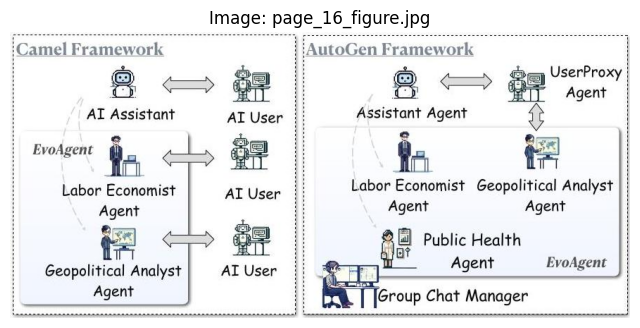

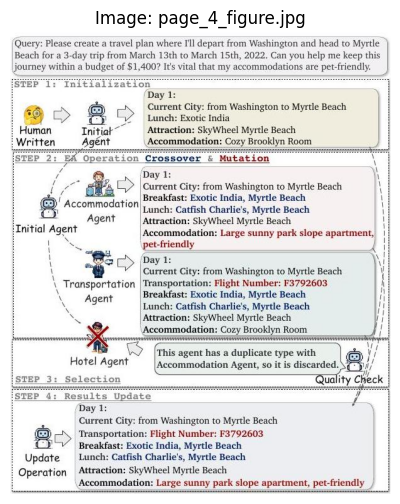

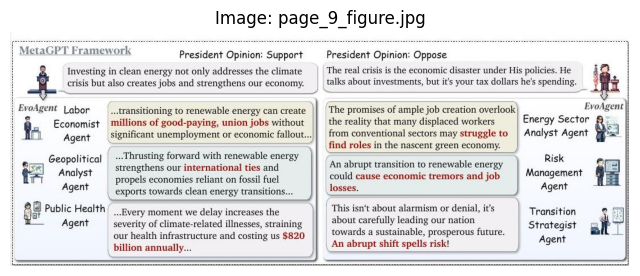

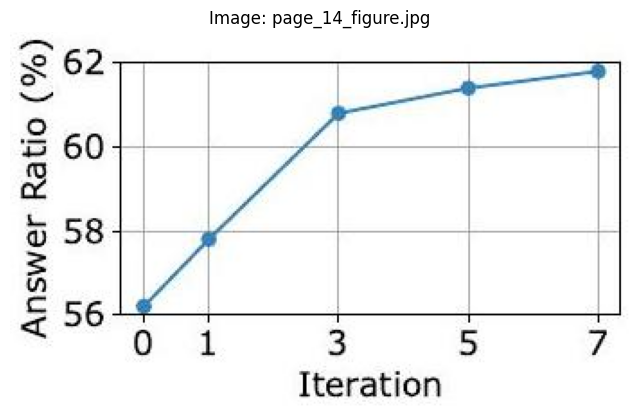

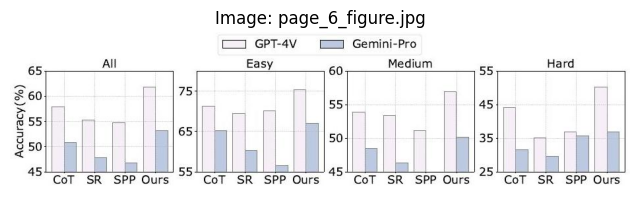

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 저장된 이미지를 시각화하는 함수
def visualize_saved_images(directory):
    """
    Given a directory, visualize all saved images.

    Args:
        directory (str): The path to the directory containing images.
    """
    if not os.path.exists(directory):
        print(f"Directory {directory} does not exist.")
        return

    image_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.endswith((".jpg", ".png", ".jpeg")):
                image_files.append(os.path.join(root, file))

    if not image_files:
        print(f"No images found in {directory}.")
        return

    print(f"Found {len(image_files)} images in {directory}. Visualizing...")

    for image_path in image_files:
        image = Image.open(image_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.title(f"Image: {os.path.basename(image_path)}")
        plt.axis('off')
        plt.show()

# Example usage
visualize_saved_images("/content/extracted_data/paper_1_content/figures")

### 후처리 추가 (같이 묶기)

                                               Title  \
0  EvoAgent: Towards Automatic Multi-Agent Genera...   
1  Cooperative Heterogeneous Deep Reinforcement L...   
2  Improving of Robotic Virtual Agent's errors th...   

                                             Summary  \
0  The rise of powerful large language models (LL...   
1  Numerous deep reinforcement learning agents ha...   
2  One way to improve the relationship between hu...   

                            PDF Link  
0  http://arxiv.org/pdf/2406.14228v2  
1  http://arxiv.org/pdf/2011.00791v1  
2  http://arxiv.org/pdf/2304.00247v2  
Downloaded: extracted_data/paper_1.pdf
Converted extracted_data/paper_1.pdf to images in extracted_data/paper_1_images


/usr/local/lib/python3.10/dist-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")



image 1/1 /content/extracted_data/paper_1_images/page_1.jpg: 1024x800 4 titles, 6 plain texts, 4 abandons, 5400.2ms
Speed: 10.6ms preprocess, 5400.2ms inference, 2.0ms postprocess per image at shape (1, 3, 1024, 800)



<ipython-input-26-d083c0f8dcb8>:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출


image 1/1 /content/extracted_data/paper_1_images/page_2.jpg: 1024x800 1 title, 8 plain texts, 1 abandon, 6776.0ms
Speed: 14.2ms preprocess, 6776.0ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_3.jpg: 1024x800 2 titles, 5 plain texts, 2 abandons, 5297.0ms
Speed: 10.3ms preprocess, 5297.0ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_4.jpg: 1024x800 1 title, 7 plain texts, 1 abandon, 1 figure, 1 figure_caption, 6690.8ms
Speed: 10.1ms preprocess, 6690.8ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


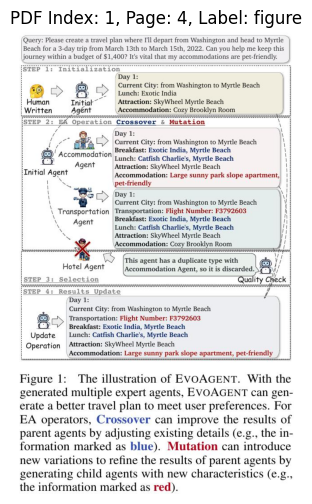


image 1/1 /content/extracted_data/paper_1_images/page_5.jpg: 1024x800 2 titles, 7 plain texts, 2 abandons, 1 table, 1 table_caption, 5445.7ms
Speed: 14.9ms preprocess, 5445.7ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


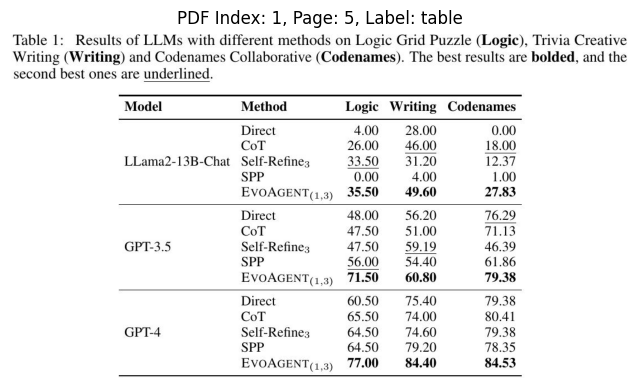


image 1/1 /content/extracted_data/paper_1_images/page_6.jpg: 1024x800 1 title, 8 plain texts, 2 abandons, 1 figure, 1 figure_caption, 6629.6ms
Speed: 14.8ms preprocess, 6629.6ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


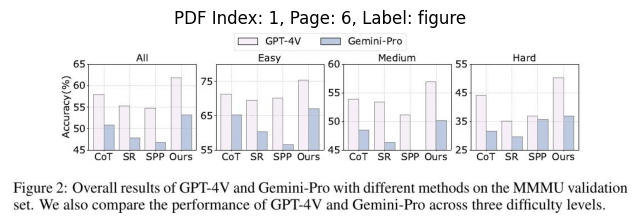


image 1/1 /content/extracted_data/paper_1_images/page_7.jpg: 1024x800 1 title, 12 plain texts, 2 abandons, 1 table, 1 table_caption, 8311.8ms
Speed: 19.4ms preprocess, 8311.8ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


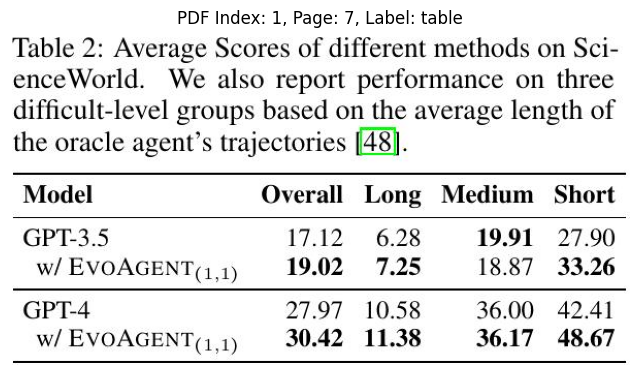


image 1/1 /content/extracted_data/paper_1_images/page_8.jpg: 1024x800 1 title, 3 plain texts, 1 abandon, 2 tables, 2 table_captions, 8428.6ms
Speed: 14.4ms preprocess, 8428.6ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


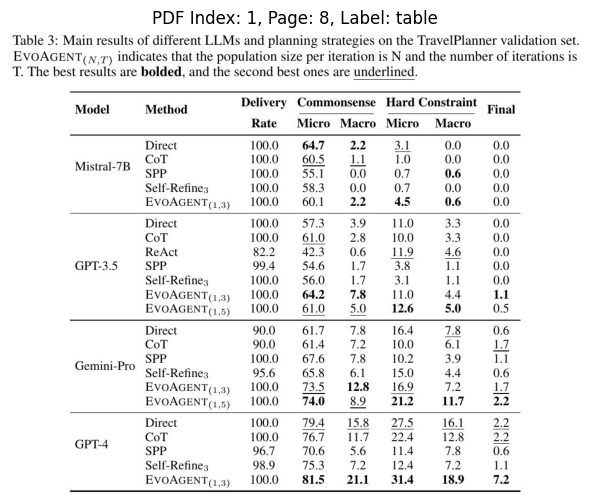

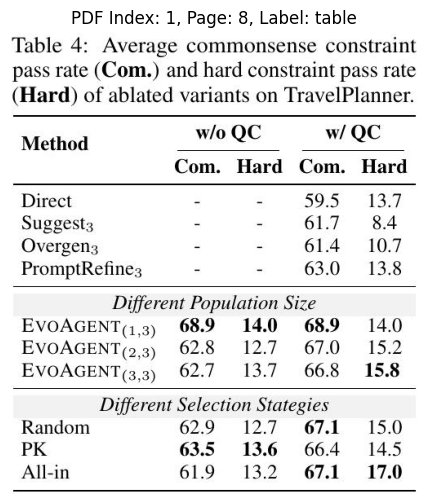


image 1/1 /content/extracted_data/paper_1_images/page_9.jpg: 1024x800 1 title, 5 plain texts, 2 abandons, 1 figure, 2 figure_captions, 8716.7ms
Speed: 14.5ms preprocess, 8716.7ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


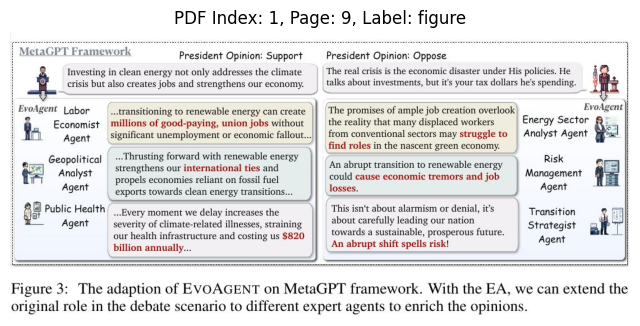


image 1/1 /content/extracted_data/paper_1_images/page_10.jpg: 1024x800 2 titles, 11 plain texts, 1 abandon, 9745.6ms
Speed: 15.6ms preprocess, 9745.6ms inference, 2.0ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_11.jpg: 1024x800 17 plain texts, 1 abandon, 6125.9ms
Speed: 15.3ms preprocess, 6125.9ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_12.jpg: 1024x800 17 plain texts, 1 abandon, 5275.3ms
Speed: 15.2ms preprocess, 5275.3ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_13.jpg: 1024x800 5 titles, 14 plain texts, 2 abandons, 6633.4ms
Speed: 15.4ms preprocess, 6633.4ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_14.jpg: 1024x800 3 titles, 8 plain texts, 1 abandon, 1 figure, 1 figure_caption, 1 table

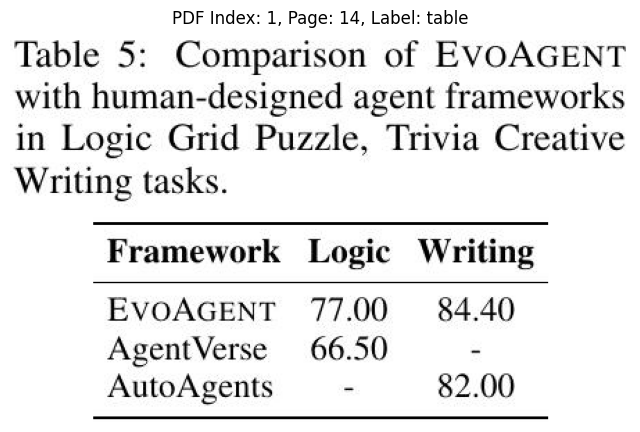

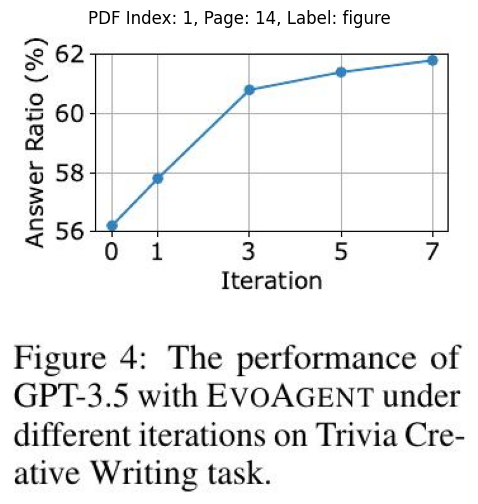


image 1/1 /content/extracted_data/paper_1_images/page_15.jpg: 1024x800 5 titles, 6 plain texts, 1 abandon, 1 table, 1 table_caption, 6256.0ms
Speed: 14.3ms preprocess, 6256.0ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)


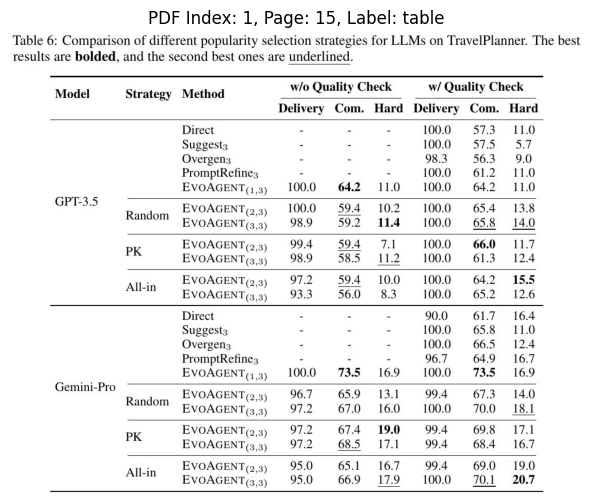


image 1/1 /content/extracted_data/paper_1_images/page_16.jpg: 1024x800 4 titles, 3 plain texts, 1 abandon, 1 figure, 1 figure_caption, 5143.1ms
Speed: 21.0ms preprocess, 5143.1ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 800)


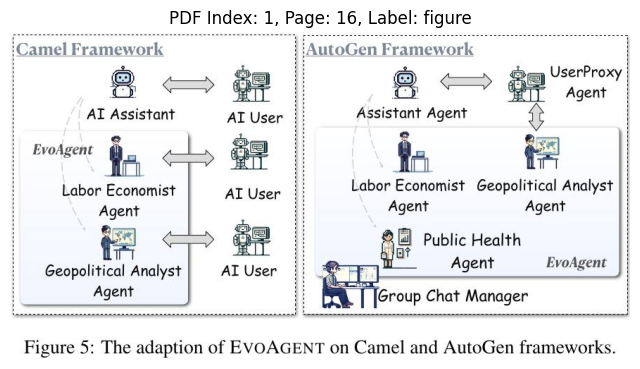


image 1/1 /content/extracted_data/paper_1_images/page_17.jpg: 1024x800 11 plain texts, 1 abandon, 6255.4ms
Speed: 13.9ms preprocess, 6255.4ms inference, 2.3ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_18.jpg: 1024x800 1 title, 11 plain texts, 2 abandons, 5210.6ms
Speed: 17.8ms preprocess, 5210.6ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_19.jpg: 1024x800 4 titles, 22 plain texts, 1 abandon, 5086.3ms
Speed: 14.7ms preprocess, 5086.3ms inference, 2.0ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_20.jpg: 1024x800 6 titles, 23 plain texts, 1 abandon, 6364.6ms
Speed: 21.5ms preprocess, 6364.6ms inference, 1.4ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_1_images/page_21.jpg: 1024x800 3 titles, 10 plain texts, 2 abandons, 5036.9ms
Speed: 15.1ms p

/usr/local/lib/python3.10/dist-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")



image 1/1 /content/extracted_data/paper_2_images/page_1.jpg: 1024x800 8 titles, 16 plain texts, 2 abandons, 5283.9ms
Speed: 14.6ms preprocess, 5283.9ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)



<ipython-input-26-d083c0f8dcb8>:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출


image 1/1 /content/extracted_data/paper_2_images/page_2.jpg: 1024x800 6 plain texts, 2 abandons, 1 figure, 1 figure_caption, 6601.3ms
Speed: 15.0ms preprocess, 6601.3ms inference, 2.3ms postprocess per image at shape (1, 3, 1024, 800)


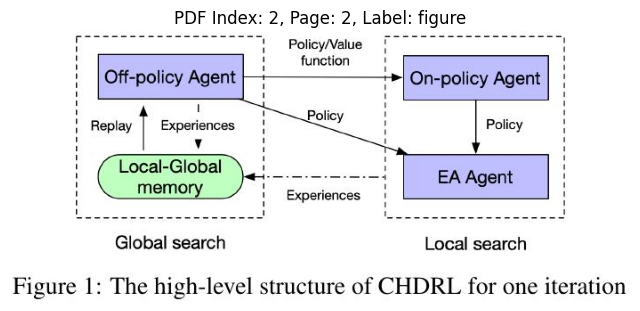


image 1/1 /content/extracted_data/paper_2_images/page_3.jpg: 1024x800 5 titles, 9 plain texts, 1 abandon, 5452.9ms
Speed: 15.0ms preprocess, 5452.9ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_2_images/page_4.jpg: 1024x800 2 titles, 9 plain texts, 1 abandon, 1 isolate_formula, 6005.9ms
Speed: 21.7ms preprocess, 6005.9ms inference, 2.0ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_2_images/page_5.jpg: 1024x800 4 titles, 6 plain texts, 1 abandon, 2 tables, 6765.5ms
Speed: 20.1ms preprocess, 6765.5ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


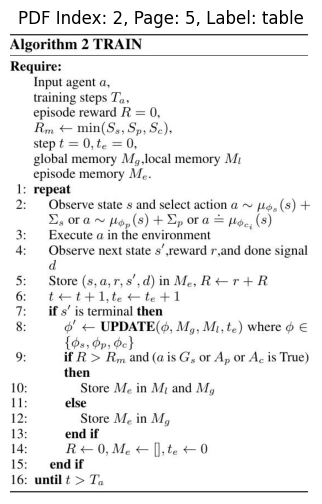

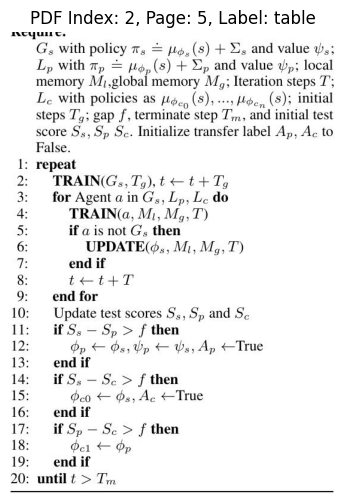


image 1/1 /content/extracted_data/paper_2_images/page_6.jpg: 1024x800 5 titles, 6 plain texts, 3 abandons, 5948.5ms
Speed: 15.4ms preprocess, 5948.5ms inference, 2.1ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_2_images/page_7.jpg: 1024x800 1 title, 3 plain texts, 1 abandon, 1 figure, 1 figure_caption, 4 tables, 2 table_captions, 6073.2ms
Speed: 25.6ms preprocess, 6073.2ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


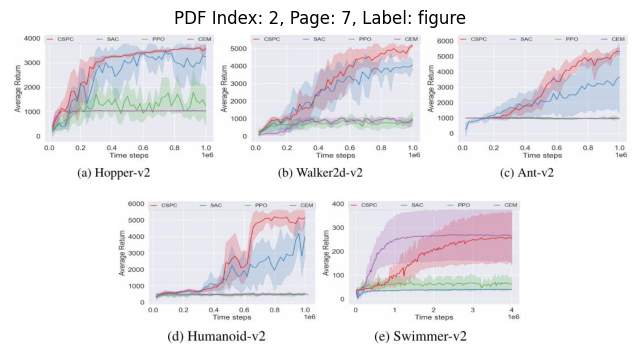

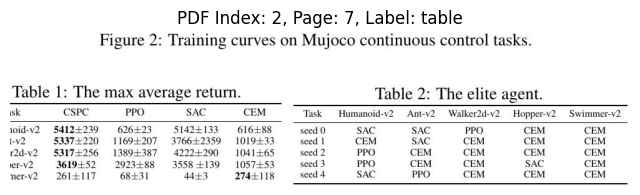

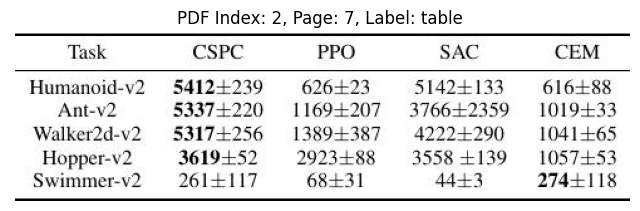

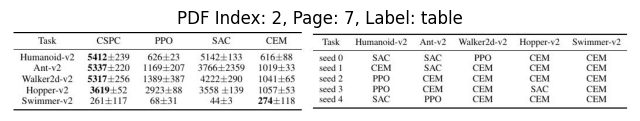

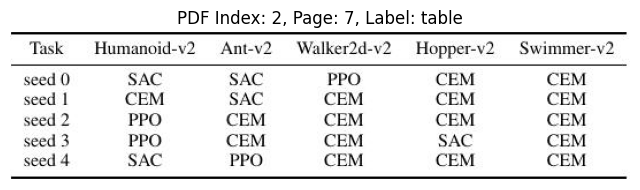


image 1/1 /content/extracted_data/paper_2_images/page_8.jpg: 1024x800 2 titles, 3 plain texts, 1 abandon, 1 figure, 1 figure_caption, 5764.8ms
Speed: 15.3ms preprocess, 5764.8ms inference, 2.4ms postprocess per image at shape (1, 3, 1024, 800)


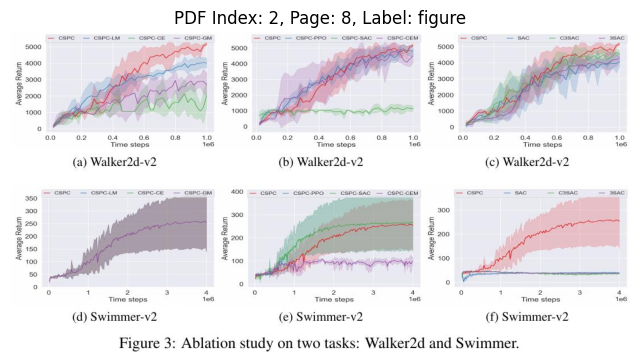


image 1/1 /content/extracted_data/paper_2_images/page_9.jpg: 1024x800 4 titles, 7 plain texts, 1 abandon, 5912.1ms
Speed: 14.4ms preprocess, 5912.1ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_2_images/page_10.jpg: 1024x800 17 plain texts, 1 abandon, 5243.9ms
Speed: 21.3ms preprocess, 5243.9ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_2_images/page_11.jpg: 1024x800 2 plain texts, 1 abandon, 6548.6ms
Speed: 20.8ms preprocess, 6548.6ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 800)
Extracted content from extracted_data/paper_2.pdf saved to extracted_data/paper_2_content
Downloaded: extracted_data/paper_3.pdf
Converted extracted_data/paper_3.pdf to images in extracted_data/paper_3_images


/usr/local/lib/python3.10/dist-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")



image 1/1 /content/extracted_data/paper_3_images/page_1.jpg: 1024x800 2 titles, 6 plain texts, 1 abandon, 5705.7ms
Speed: 23.0ms preprocess, 5705.7ms inference, 2.1ms postprocess per image at shape (1, 3, 1024, 800)



<ipython-input-26-d083c0f8dcb8>:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출


image 1/1 /content/extracted_data/paper_3_images/page_2.jpg: 1024x800 1 title, 6 plain texts, 1 abandon, 5955.6ms
Speed: 19.9ms preprocess, 5955.6ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_3.jpg: 1024x800 2 titles, 4 plain texts, 2 abandons, 5216.5ms
Speed: 15.1ms preprocess, 5216.5ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_4.jpg: 1024x800 1 title, 8 plain texts, 1 abandon, 6547.0ms
Speed: 15.3ms preprocess, 6547.0ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_5.jpg: 1024x800 1 title, 3 plain texts, 2 abandons, 1 figure, 2 figure_captions, 5210.6ms
Speed: 17.0ms preprocess, 5210.6ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)


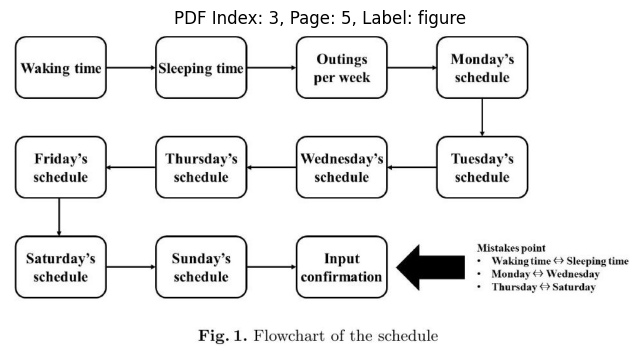


image 1/1 /content/extracted_data/paper_3_images/page_6.jpg: 1024x800 1 title, 3 plain texts, 2 abandons, 1 figure, 1 figure_caption, 1 table_caption, 6442.3ms
Speed: 15.5ms preprocess, 6442.3ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)


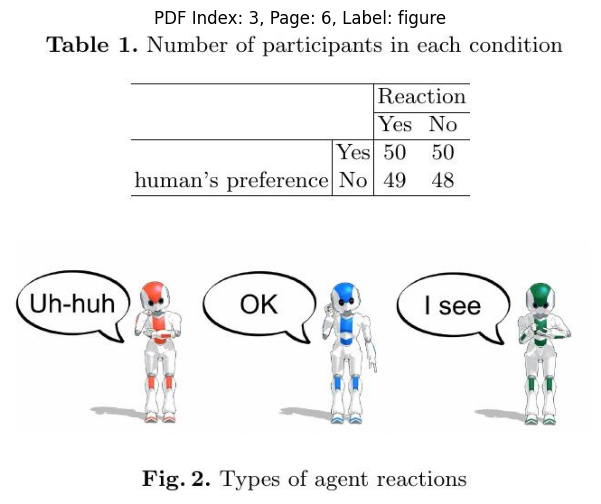


image 1/1 /content/extracted_data/paper_3_images/page_7.jpg: 1024x800 2 titles, 4 plain texts, 2 abandons, 1 figure, 1 figure_caption, 5217.9ms
Speed: 14.2ms preprocess, 5217.9ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 800)


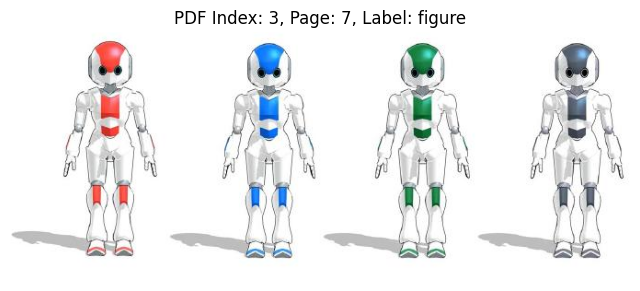


image 1/1 /content/extracted_data/paper_3_images/page_8.jpg: 1024x800 3 titles, 4 plain texts, 2 abandons, 1 table, 1 table_caption, 6260.9ms
Speed: 15.1ms preprocess, 6260.9ms inference, 2.2ms postprocess per image at shape (1, 3, 1024, 800)


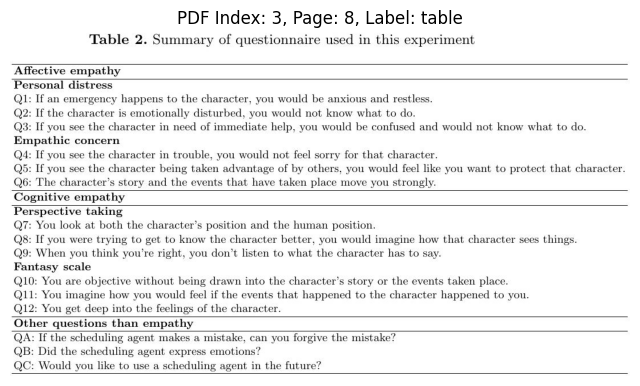


image 1/1 /content/extracted_data/paper_3_images/page_9.jpg: 1024x800 2 abandons, 3 tables, 3 table_captions, 2 table_footnotes, 5308.6ms
Speed: 18.5ms preprocess, 5308.6ms inference, 1.7ms postprocess per image at shape (1, 3, 1024, 800)


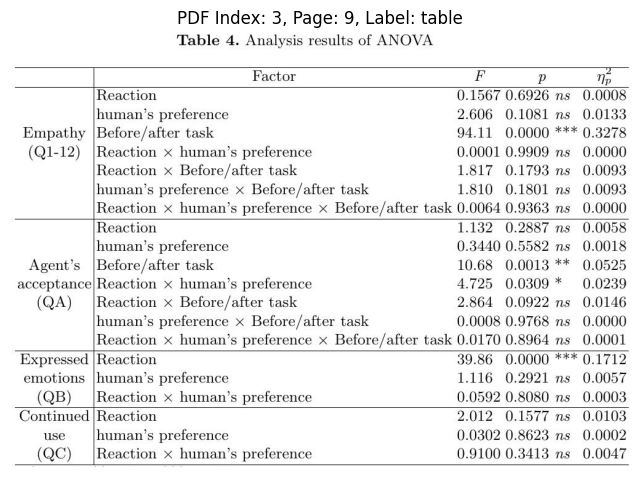

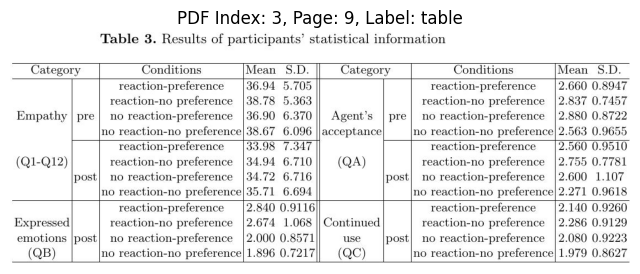

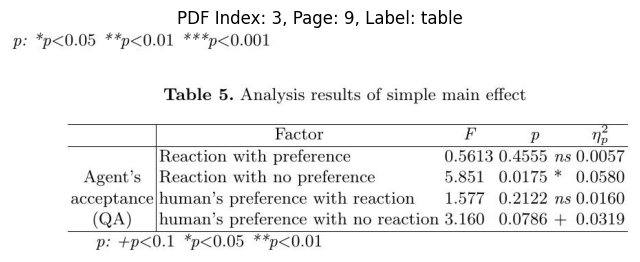


image 1/1 /content/extracted_data/paper_3_images/page_10.jpg: 1024x800 2 titles, 5 plain texts, 1 abandon, 1 figure, 1 figure_caption, 5779.1ms
Speed: 15.4ms preprocess, 5779.1ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 800)


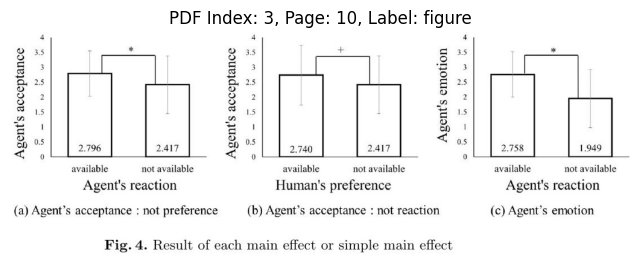


image 1/1 /content/extracted_data/paper_3_images/page_11.jpg: 1024x800 2 titles, 6 plain texts, 2 abandons, 5695.4ms
Speed: 15.1ms preprocess, 5695.4ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_12.jpg: 1024x800 2 titles, 3 plain texts, 1 abandon, 5254.5ms
Speed: 15.0ms preprocess, 5254.5ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 800)

image 1/1 /content/extracted_data/paper_3_images/page_13.jpg: 1024x800 1 plain text, 2 abandons, 6512.9ms
Speed: 14.5ms preprocess, 6512.9ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 800)
Extracted content from extracted_data/paper_3.pdf saved to extracted_data/paper_3_content
Detection metadata saved to extracted_data/detection_metadata.csv.


In [ ]:
import os
import pandas as pd
from langchain.document_loaders import ArxivLoader
from pdf2image import convert_from_path
from huggingface_hub import hf_hub_download
import cv2
from doclayout_yolo import YOLOv10
from PIL import Image
import matplotlib.pyplot as plt

# ArxivLoader를 활용해 논문을 가져옵니다
loader = ArxivLoader(
    query="Agent",
    load_max_docs=20,              # 최대 문서 수
    load_all_available_meta=True   # 메타데이터 전체 로드 여부
)
docs = loader.load()

# 메타데이터 정보를 데이터프레임으로 저장
metadata_list = []
for doc in docs:
    metadata = doc.metadata
    metadata_list.append({
        'Title': metadata.get('Title', ''),
        'Summary': metadata.get('Summary', ''),
        'PDF Link': metadata.get('links', [])[-1] if metadata.get('links') else ''
    })

dataframe = pd.DataFrame(metadata_list)

# 데이터프레임 확인
print(dataframe)

# DocLayout-YOLO 및 필수 패키지 설치
os.system("pip install git+https://github.com/opendatalab/DocLayout-YOLO.git")
os.system("pip install pdf2image huggingface_hub matplotlib")
os.system("sudo apt-get install poppler-utils")

# PDF 다운로드 함수
def download_pdf(pdf_url, filename):
    import requests
    response = requests.get(pdf_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f"Downloaded: {filename}")

# PDF를 이미지로 변환
def convert_pdf_to_images(pdf_path, output_dir):
    try:
        os.makedirs(output_dir, exist_ok=True)
        images = convert_from_path(pdf_path)
        image_paths = []
        for i, image in enumerate(images):
            image_path = os.path.join(output_dir, f"page_{i+1}.jpg")
            image.save(image_path, "JPEG")
            image_paths.append(image_path)
        print(f"Converted {pdf_path} to images in {output_dir}")
        return image_paths
    except Exception as e:
        print(f"Error converting {pdf_path} to images: {e}")
        return []

# DocLayout-YOLO를 활용한 디텍션 및 저장

def extract_content_with_doclayout_yolo(image_paths, output_dir, pdf_index):
    os.makedirs(output_dir, exist_ok=True)

    # Pre-trained 모델 다운로드 및 로드
    model_path = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
    model = YOLOv10(model_path)

    metadata = []

    for page_number, image_path in enumerate(image_paths, start=1):
        # 모델 예측
        det_res = model.predict(
            source=image_path,   # 이미지 경로
            imgsz=1024,          # 예측 이미지 크기
            conf=0.2,            # 신뢰도 임계값
            device="cpu"         # CPU에서 실행
        )

        # 결과 필터링 및 그룹화
        elements = []
        for det in det_res[0].boxes:
            bbox = det.xyxy.numpy().flatten()  # 바운딩 박스 좌표 추출
            cls = int(det.cls.cpu().numpy())  # 클래스 인덱스 추출
            label = model.names[cls]

            if label in ["table", "table_caption", "table_footnote", "figure", "figure_caption"]:
                elements.append({"label": label, "bbox": bbox, "image_path": image_path})

        # 요소 그룹화 (table 및 figure 기반으로 묶기)
        grouped_elements = []
        for element in elements:
            if element["label"] in ["table", "figure"]:
                grouped_elements.append({"base": element, "related": []})
            else:
                # 가까운 base 요소에 연결
                closest_base = None
                min_distance = float("inf")
                for group in grouped_elements:
                    base_bbox = group["base"]["bbox"]
                    distance = abs(base_bbox[1] - element["bbox"][1])  # Y축 거리
                    if distance < min_distance:
                        closest_base = group
                        min_distance = distance
                if closest_base:
                    closest_base["related"].append(element)

        # 그룹화된 요소 저장
        for group in grouped_elements:
            base = group["base"]
            related = group["related"]

            # 바운딩 박스 확장
            combined_bbox = base["bbox"]
            for rel in related:
                combined_bbox = [
                    min(combined_bbox[0], rel["bbox"][0]),
                    min(combined_bbox[1], rel["bbox"][1]),
                    max(combined_bbox[2], rel["bbox"][2]),
                    max(combined_bbox[3], rel["bbox"][3]),
                ]

            # 이미지 저장
            image = Image.open(base["image_path"])
            cropped = image.crop((combined_bbox[0], combined_bbox[1], combined_bbox[2], combined_bbox[3]))

            output_label_dir = os.path.join(output_dir, base["label"] + "s")
            os.makedirs(output_label_dir, exist_ok=True)
            output_image_path = os.path.join(output_label_dir, f"page_{page_number}_{base['label']}.jpg")
            cropped.save(output_image_path)

            # 예시 이미지 출력
            plt.figure(figsize=(8, 6))
            plt.imshow(cropped)
            plt.title(f"PDF Index: {pdf_index}, Page: {page_number}, Label: {base['label']}")
            plt.axis('off')
            plt.show()

            metadata.append({
                "pdf_index": pdf_index,
                "page_number": page_number,
                "label": base["label"],
                "related_labels": [rel["label"] for rel in related],
                "bbox": combined_bbox,
                "output_path": output_image_path
            })

    return metadata

# PDF 다운로드 및 콘텐츠 추출 함수
def save_pdfs_and_extract_content(dataframe):
    extracted_data_dir = "extracted_data"
    os.makedirs(extracted_data_dir, exist_ok=True)

    all_metadata = []

    for index, row in dataframe.iterrows():
        pdf_link = row['PDF Link']
        title = row['Title']
        if pdf_link:
            pdf_filename = os.path.join(extracted_data_dir, f"paper_{index+1}.pdf")
            download_pdf(pdf_link, pdf_filename)

            # PDF를 이미지로 변환
            image_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_images")
            image_paths = convert_pdf_to_images(pdf_filename, image_output_dir)

            if image_paths:
                # DocLayout-YOLO 디텍션 및 결과 저장
                content_output_dir = os.path.join(extracted_data_dir, f"paper_{index+1}_content")
                metadata = extract_content_with_doclayout_yolo(image_paths, content_output_dir, pdf_index=index+1)
                all_metadata.extend(metadata)
                print(f"Extracted content from {pdf_filename} saved to {content_output_dir}")

    # 메타데이터를 CSV로 저장
    metadata_df = pd.DataFrame(all_metadata)
    metadata_df.to_csv(os.path.join(extracted_data_dir, "detection_metadata.csv"), index=False)
    print(f"Detection metadata saved to {os.path.join(extracted_data_dir, 'detection_metadata.csv')}.")

# 함수 실행
save_pdfs_and_extract_content(dataframe)

In [ ]:
last_detect = pd.read_csv('detection_metadata.csv')
last_detect

### reference 및 참고

- https://huggingface.co/spaces/opendatalab/DocLayout-YOLO
- https://github.com/opendatalab/DocLayout-YOLO?tab=readme-ov-file
- https://github.com/opendatalab/PDF-Extract-Kit

In [ ]:
# Pre-trained 모델 다운로드 및 로드
model_path = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
model = YOLOv10(model_path)

# 모델에서 지원하는 레이블 목록 출력
print("Available labels:", model.names)

/usr/local/lib/python3.10/dist-packages/doclayout_yolo/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


Available labels: {0: 'title', 1: 'plain text', 2: 'abandon', 3: 'figure', 4: 'figure_caption', 5: 'table', 6: 'table_caption', 7: 'table_footnote', 8: 'isolate_formula', 9: 'formula_caption'}


## 추가 처리 (사용 미정)

- 사이즈가 카테고리별로도 다 다를 것
- Bounding Box의 크기의 중앙값 사용
- 특징에 뚜렷한 차이가 있는지도 확인하기
- 비슷하면 resize 하는데 표준으로

In [ ]:
# 의미가 딱히 없을 수 있어서 보류

## CLIP embedding

- fine-tuning된 clip 사용
- text, image에 대한 encoder를 사용해 학습
- 하나의 벡터 space에 text, image에 대한 정보 반영되게 training됨
- text, image 상호 동작하는 embedding vector를 만들 수 있음
- zero shot inference가 가능

다른 가능한 방법 생각

- ChartOCR + NLP
  - 그래프에 포함된 텍스트(축, 레이블, 데이터 값)를 읽는 데는 ChartOCR 기술이 유용
  - OCR을 통해 텍스트를 추출한 후 NLP 모델을 통해 그래프를 해석하는 방식

- Pix2Struct
  - 차트와 같은 시각적 입력을 구조화된 데이터로 변환하는 데 탁월
  - 차트에서 텍스트, 데이터, 구조 정보 추출
  - 텍스트 기반 트렌드 설명 생성
    - https://huggingface.co/docs/transformers/model_doc/pix2struct
    - finetune : https://www.kaggle.com/code/mnavaidd/fine-tune-pix2struct-on-a-key-value-pair-dataset
    - https://replicate.com/cjwbw/pix2struct/examples
    - https://colab.research.google.com/github/openvinotoolkit/openvino_notebooks/blob/main/notebooks/260-pix2struct-docvqa/260-pix2struct-docvqa.ipynb

- BLIP

### Base Embedding

## 평가

- HITS@5 : 이미지 가져올 때 실제로 연관 있는 이미지 몇 개 나오는지 계산